# Visión por Computadora II - 2025 - B4 - Trabajo práctico integrador
**Inteligencia Artificial - CEIA - FIUBA**

## Autores

- **Mendoza Dante**.

- **Vasquez Jorge**.

- **Viñas Gustavo**.

**Dataset elegido:** https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset

**Descripcion:** Detección de enfermedades en cultivos agrícolas. Entrenar un modelo que identifique y clasifique enfermedades en plantas a partir de imágenes, ayudando a los agricultores a tomar medidas preventivas y reducir pérdidas.​

**Enfoque:** Entrenar un modelo para identificar una enfermedad específica en una especie de planta utilizando imágenes.​

# 💻 Montaje de entorno y definición de rutas

- Definir entorno de proyecto.

- Visualizar las rutas del dataset.

In [1]:
%pip install --quiet pandas matplotlib scikit-learn torch torchvision torchinfo

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import os
from zipfile import ZipFile

# Funcion auxiliar para descargar el dataset
def download_dataset(target_dir, subset: str | None = None, force: bool = False):
    dataset_url = "https://www.kaggle.com/api/v1/datasets/download/abdallahalidev/plantvillage-dataset"
    dataset_folder = "plantvillage dataset"
    tmp_file = "tmp.zip"

    if not(subset is None or subset.lower() in ["color", "grayscale", "segmented"]):
        raise Exception("subset debe ser None, color, grayscale o segmented")

    if os.path.isdir(target_dir) and not force:
        if subset is None:
            print("Dataset folder already exists, nothing downloaded.")
            return
        if os.path.isdir(os.path.join(target_dir, subset)):
            print(f"Folder already exists for subset \"{subset}\", nothing downloaded.")
            return

    try:
        with requests.get(dataset_url, stream=True) as response:
            response.raise_for_status()  # Raise an exception for bad status codes

            with open(tmp_file, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
        print(f"File '{tmp_file}' downloaded successfully.")
    except requests.exceptions.RequestException as e:
        if (os.path.isfile(tmp_file)):
            os.remove(tmp_file)
        raise(Exception(f"Error downloading file: {e}"))

    try:
        with ZipFile(tmp_file, 'r') as zip_object:
            for member in zip_object.infolist():
                if member.filename.startswith(dataset_folder):
                    member.filename = member.filename[len(dataset_folder)+1:]
                    if subset is None or member.filename.startswith(subset):
                        zip_object.extract(member, target_dir)
        print(f"Successfully extracted '{tmp_file}' to '{target_dir}' for " + ('all subsets' if subset is None else f"{subset} subset") + ".")

    except FileNotFoundError:
        raise(Exception(f"Error: The file '{tmp_file}' was not found."))
    except Exception as e:
        raise(Exception(f"An error occurred: {e}"))
    finally:
        if (os.path.isfile(tmp_file)):
            os.remove(tmp_file)


In [3]:
# ====================================================
# MONTAJE DE ENTORNO Y DEFINICIÓN DE RUTAS
# ====================================================

# Descargamos el dataset si no existe la carpeta
base_dir = "datasets"
subset = "color"
download_dataset(base_dir, subset)


# Ruta al dataset
DATASET_PATH = os.path.join(base_dir, subset)

print("Ruta del dataset:", DATASET_PATH)
print("Listado de carpetas:", os.listdir(DATASET_PATH)[:10])

File 'tmp.zip' downloaded successfully.
Successfully extracted 'tmp.zip' to 'datasets' for color subset.
Ruta del dataset: datasets\color
Listado de carpetas: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


# 💻 Preparamos el dataset (split + DataLoader)

- Vamos a tomar todas las clases.

- Creamos carpetas train/val/test con split 70/15/15.

- Definimos DataLoader en PyTorch con transformaciones (resize, normalización, data augmentation).

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

class TransformationDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        if self.transform:
            x = self.transform(self.dataset[index][0])
        else:
            x = self.dataset[index][0]
        y = self.dataset[index][1]
        return x, y

    def __len__(self):
        return len(self.dataset)

In [5]:
import random
from collections import Counter
import numpy as np
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

batch_size = 128 # Definimos 128, ya que al ser 38 clases, 32 o 64 no es suficiente para tener al menos una muestra de cada clase en cada batch
img_size = (224,224) # Tamaño mínimo para modelos preentrenados, utilizamos el mismo tamaño para nuestro modelo

full_dataset = datasets.ImageFolder(DATASET_PATH)

targets = [s[1] for s in full_dataset.samples] # Descomentar si se quiere usar todo el dataset
# targets = [s[1] for s in random.sample(full_dataset.samples, 10000)] # Descomentar si se quiere usar solo una muestra del dataset

# Usamos train_test_split para hacer splits estratificados que conserven la distribución de clases
train_idx, test_idx = train_test_split(np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.25, stratify=np.array(targets)[train_idx], random_state=42) # 0.25 of 0.8 is 0.2

train_dataset = Subset(full_dataset, train_idx) # 0.6
val_dataset = Subset(full_dataset, val_idx)     # 0.2
test_dataset = Subset(full_dataset, test_idx)    # 0.2

transform_train = transforms.Compose([
    # Creamos variantes de las imagenes para evitar overfitting al hacer oversampling
    transforms.RandomCrop(img_size), # En train hacemos random crop a img_size
    transforms.RandomRotation(15), # En train hacemos rotaciones aleatorias de hasta 15 grados
    transforms.RandomHorizontalFlip(), # En train hacemos flip horizontal aleatorio
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Variaciones de brillo y contraste. No hacemos variaciones de color para no perder info de la hoja y enfermedades.
    transforms.ToTensor(), # Escala entre 0 y 1; pasa a tensor; poner canales en 1ra dim
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

transform_val_test = transforms.Compose([
    transforms.CenterCrop(img_size), # En validación y test hacemos center crop a img_size
    transforms.ToTensor(),# Escala entre 0 y 1; pasa a tensor; poner canal en 1ra dim
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Calculo pesos de las clases para balancear el dataset de entrenamiento
class_counts = Counter(np.array(targets)[train_idx])
num_samples = sum(class_counts.values())
class_weights = {cls: num_samples / count for cls, count in class_counts.items()}
sample_weights = [class_weights[target] for target in np.array(targets)[train_idx]]

# Balanceo de clases en entrenamiento usando WeightedRandomSampler.
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dataloader = DataLoader(TransformationDataset(train_dataset, transform_train), batch_size=batch_size, pin_memory=True, sampler=sampler)
val_dataloader = DataLoader(TransformationDataset(val_dataset, transform_val_test), batch_size=batch_size, shuffle=False, pin_memory=True)
test_dataloader = DataLoader(TransformationDataset(test_dataset, transform_val_test), batch_size=batch_size, shuffle=False, pin_memory=True)


In [6]:
# Comprobamos que no hay solapamiento entre los splits
print(f"Solapamiento entre train y test: {len(set(train_idx) & set(test_idx))}")
print(f"Solapamiento entre train y val: {len(set(train_idx) & set(val_idx))}")
print(f"Solapamiento entre test y val: {len(set(test_idx) & set(val_idx))}")

Solapamiento entre train y test: 0
Solapamiento entre train y val: 0
Solapamiento entre test y val: 0


In [7]:
print("Distribucion de muestras:")
print("\nFull: ", len(full_dataset), "\nTrain:", len(train_dataset), "\nVal:", len(val_dataset), "\nTest:", len(test_dataset))
print(f"\nNúmero de clases totales: {len(full_dataset.classes)}.")

Distribucion de muestras:

Full:  54305 
Train: 32583 
Val: 10861 
Test: 10861

Número de clases totales: 38.


In [8]:
print("Clases -> ids:")
idx_to_class = {v: i for i,v in full_dataset.class_to_idx.items()}
print(full_dataset.class_to_idx)
print("Ids -> clases:")
print(idx_to_class)

Clases -> ids:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_bligh

In [9]:
# Cargamos un batch del dataloader para probar que todo este ok
train_features, train_labels = next(iter(train_dataloader))
len(train_features), len(train_labels)

(128, 128)

In [10]:
# verificamos sus dimensiones
print(f"Tamaño del batch de feature (input / imagen): {train_features.size()}")
print(f"Tamaño del batch del label (clase / etiqueta): {train_labels.size()}")

Tamaño del batch de feature (input / imagen): torch.Size([128, 3, 224, 224])
Tamaño del batch del label (clase / etiqueta): torch.Size([128])


tamaño de 1 imagen:  torch.Size([1, 3, 224, 224])
tamaño de 1 imagen DESPUES de squeeze:  torch.Size([224, 224, 3])


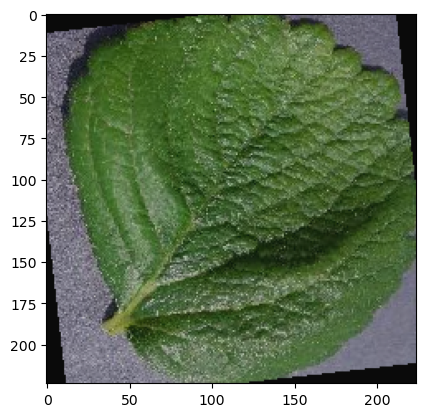

Label: 27 (Strawberry___healthy)


In [11]:
import torch
import matplotlib.pyplot as plt

# tomamos 1 imagen para poder visualizarla y verificar sus dimensiones
img_idx = torch.randint(len(train_features), (1,))
img = train_features[img_idx]
print('tamaño de 1 imagen: ', img.shape)
# le quitamos 1 dimension (la del tamaño del batch) y reordenamos para poder graficar
img = img.squeeze().permute(1, 2, 0)
print('tamaño de 1 imagen DESPUES de squeeze: ', img.shape)
label = train_labels[img_idx]

# Unnormalize
img = np.array([0.229, 0.224, 0.225]) * img.numpy() + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1) # Clip values to be between 0 and 1

# ploteo esa imagen
plt.imshow(img)
plt.show()
print(f"Label: {label.item()} ({idx_to_class[label.item()]})")

# 💻 Modelo Base + optimización de hiperparámetros

- Viendo que el modelo base tiene un accuracy y F1 score muy buenos, con una arquitectura mucho más simple, nos centraremos en intentar optimizarlo aun más


Creamos una clase para guardar métricas (y luego graficar).

In [12]:
# A simple metric tracker
class MetricTracker:
    def __init__(self):
        self.metrics = {}

    def update(self, metric_name, value):
        if metric_name not in self.metrics:
            self.metrics[metric_name] = []
        self.metrics[metric_name].append(value)

    def get_latest(self, metric_name):
        if metric_name in self.metrics and self.metrics[metric_name]:
            return self.metrics[metric_name][-1]
        return None

    def get_all(self, metric_name):
        return self.metrics.get(metric_name, [])

    def reset(self):
        self.metrics = {}

    def plot_metrics(self, metric_names=None, figsize=(12, 6)):
        """Plot training metrics"""
        if metric_names is None:
            metric_names = list(self.metrics.keys())

        plt.figure(figsize=figsize)
        for metric_name in metric_names:
            values = self.get_all(metric_name)
            if values:
                plt.plot(values, label=metric_name)

        plt.title('Training Metrics')
        plt.xlabel('Epocs')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

Seleccionamos el dispositivo donde se ejecutará el entrenamiento

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Definimos la clase SimpleCNN

In [14]:
from torch import nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(SimpleCNN, self).__init__()
        # First convolutional layer
        # Input channels: 3 (for RGB images)
        # Output channels: 16
        # Kernel size: 5x5
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=1)
        # Max pooling layer
        # Kernel size: 3x3
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)
        # Second convolutional layer
        # Input channels: 16
        # Output channels: 32
        # Kernel size: 3x3
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Third convolutional layer
        # Input channels: 32
        # Output channels: 64
        # Kernel size: 3x3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Fully connected layers
        # The input size to the first fully connected layer depends on the image size
        # and the pooling layers. For a 224x224 input image with three 2x2 pooling layers,
        # the feature map size becomes (224 / 3 / 3 / 3) x (224 / 3 / 3 / 3) = 8x8.
        # So, the input features will be 64 * 8 * 8.
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Apply first conv layer, ReLU activation, and max pooling
        x = self.pool(F.relu(self.conv1(x)))
        # Apply second conv layer, ReLU activation, and max pooling
        x = self.pool(F.relu(self.conv2(x)))
        # Apply third conv layer, ReLU activation, and max pooling
        x = self.pool(F.relu(self.conv3(x)))
        # Flatten the output for the fully connected layers
        x = x.view(-1, 64 * 8 * 8) # Reshape for FC layer
        # Apply first fully connected layer with ReLU activation
        x = F.relu(self.fc1(x))
        # Apply second fully connected layer with ReLU activation
        x = F.relu(self.fc2(x))
        # Apply second fully connected layer (output layer)
        x = self.fc3(x)
        return x

# Se probaron otras combinaciones de hiperparámetros, pero estas dieron mejores resultados
# Por ejemplo, con convoluciones de 5/5/3 y LR 0.01 no convergía bien

Creamos la función de entrenamiento modificada para la búsqueda de hiperparámetros

In [15]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

fast = True # Para evaluar solo el 50% de los batches

# función de entrenamiento
def optimizer_fit(trial, model, dataloader, criterion, optimizer, scheduler, epochs=15, patience=3, patience_factor=0.01):
    lr = optimizer.param_groups[0]['lr']
    best_model = 0
    best_eval = 0
    pt_epoch = 0
    # enviamos el modelo al device
    model.to(device)
    # iteramos en las epocas
    bar = tqdm(range(epochs))
    for epoch in bar:
        # ponemos el modelo en train
        model.train()
        train_loss = 0
        for i, batch in enumerate(dataloader['train']):
            if fast and i > len(dataloader['train']) * 0.5: break
            X, y = batch  # sacamos X e y del batch
            X, y = X.to(device), y.to(device) # lo enviamos al device
            optimizer.zero_grad() # llevamos optimizer a zero
            y_hat = model(X)  # corremos el modelo y vemos su predicción
            loss = criterion(y_hat, y)  # calculamos la pérdida
            loss.backward() # back-propagations
            optimizer.step() # step del optimizer
            scheduler.step() # Step-level callback
            train_loss += loss.item()
            bar.set_description(f"trial {trial.number}. LR {lr:.6f}. batch {i+1}/{len(dataloader['train'])}. loss {train_loss/(i+1):.5f}. epoch")

        # ahora evaluamos test
        eval_loss = 0.0
        valid_epoch_y_hat = []
        valid_epoch_y = []
        # ponemos en eval el modelo
        model.eval()
        with torch.no_grad():
            for i, batch in enumerate(dataloader['val']):
                if fast and i > len(dataloader['val']) * 0.5: break
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)

                eval_loss += loss.item()
                # Almaceno los valores reales y mis predicciones para cálcular las métricas
                valid_epoch_y += list(y.detach().cpu().numpy())
                valid_epoch_y_hat += list(y_hat.detach().cpu().numpy())
                bar.set_description(f"trial {trial.number}. LR {lr:.6f}. batch {i+1}/{len(dataloader['val'])}. val_loss {eval_loss/(i+1):.5f}. epoch")

        # Cálculo la métrica de la epoch
        # Compute evaluation metrics
        eval_loss /= len(dataloader['val'])
        eval_preds_classes = np.argmax(valid_epoch_y_hat, axis=1)
        eval_accuracy = accuracy_score(valid_epoch_y, eval_preds_classes)
        eval_f1 = f1_score(valid_epoch_y, eval_preds_classes, average='macro')

        if eval_accuracy>best_model:
            best_model = eval_accuracy
        bar.set_description(f"trial {trial.number}. LR {lr:.6f}. best eval_accuracy {best_model:.5f}. epoch")
        ## Early stopping
        if eval_accuracy>=best_eval*(1+patience_factor):
            best_eval = eval_accuracy
            pt_epoch = 0
        else:
            pt_epoch += 1
            if pt_epoch>=patience:
                break

    return best_model

Creamos el experimento de Optuna

In [16]:
def champion_callback(study, frozen_trial):
    """
    Mostramos menos información, sino es demasiado verboso
    """
    # Obtener el mejor valor previo registrado en user_attrs
    winner = study.user_attrs.get("winner", None)
    
    # Si el valor actual supera al ganador anterior
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        
        if winner:
            # Calcular la mejora porcentual
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value:.5f} with "
                f"{improvement_percent:.2f}% improvement"
            )
        else:
            # Primer ganador registrado
            print(f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value:.5f}")
    elif frozen_trial.number % 10 == 0:
        # Mostrar progreso cada 10 trials
        print(f"Trial {frozen_trial.number} with no changes.")

def objective(trial, dataloader):

    # En esta prueba solo buscamos mejores hiperparámetros para learning rate.
    # Sería una mejor prueba modificar el modelo para parametrizar cantidad de capas convolucionales, 
    # cantidad de fully connected, tamaños de kernel y/o hidden layers.

    steps_per_epoch = len(dataloader["train"])
    dset_classes_number = len(train_dataset.dataset.class_to_idx)
    model_simple_cnn = SimpleCNN(num_classes=dset_classes_number)

    # Según las pruebas realizadas, probamos en un rango cercano al LR que mejor funcionó (0.001, sabiendo que 0.01 era peor)
    lr = trial.suggest_float("lr", 0.0001, 0.005, log=True)
    optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr=lr, weight_decay=0.001)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch, T_mult=2, eta_min=1e-5)    

    score = optimizer_fit(trial, model_simple_cnn, dataloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, 
                                    epochs=10, patience=3, patience_factor=0.01)
    
    return score


In [17]:
import optuna 
# Creamos un estudio de Optuna
# Optuna es un poco verboso, dejamos que solo nos muestre logs de errores
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="maximize")
dataloader = { 'train': train_dataloader, 'val': val_dataloader }
study.optimize(lambda trial: objective(trial, dataloader), n_trials=15, callbacks=[champion_callback])

trial 0. LR 0.003940. best eval_accuracy 0.80069. epoch:  70%|███████   | 7/10 [05:50<02:30, 50.12s/it]   


Initial trial 0 achieved value: 0.80069


trial 1. LR 0.001031. best eval_accuracy 0.90062. epoch: 100%|██████████| 10/10 [07:21<00:00, 44.19s/it]  


Trial 1 achieved value: 0.90062 with 11.10% improvement


trial 2. LR 0.002733. best eval_accuracy 0.85320. epoch:  70%|███████   | 7/10 [05:55<02:32, 50.78s/it]   
trial 3. LR 0.002389. best eval_accuracy 0.89408. epoch: 100%|██████████| 10/10 [07:22<00:00, 44.23s/it]  
trial 4. LR 0.002474. best eval_accuracy 0.85919. epoch:  70%|███████   | 7/10 [05:52<02:31, 50.40s/it]   
trial 5. LR 0.000455. best eval_accuracy 0.83866. epoch: 100%|██████████| 10/10 [07:24<00:00, 44.40s/it]  
trial 6. LR 0.000578. best eval_accuracy 0.86610. epoch: 100%|██████████| 10/10 [07:23<00:00, 44.35s/it]  
trial 7. LR 0.001427. best eval_accuracy 0.88645. epoch:  70%|███████   | 7/10 [05:56<02:32, 50.91s/it]   
trial 8. LR 0.000329. best eval_accuracy 0.81668. epoch: 100%|██████████| 10/10 [07:22<00:00, 44.30s/it]  
trial 9. LR 0.002504. best eval_accuracy 0.81995. epoch:  70%|███████   | 7/10 [05:53<02:31, 50.53s/it]   
trial 10. LR 0.000128. best eval_accuracy 0.70640. epoch: 100%|██████████| 10/10 [07:22<00:00, 44.24s/it]  


Trial 10 with no changes.


trial 11. LR 0.001147. best eval_accuracy 0.86101. epoch:  70%|███████   | 7/10 [05:54<02:32, 50.69s/it]   
trial 12. LR 0.001179. best eval_accuracy 0.85138. epoch:  70%|███████   | 7/10 [05:53<02:31, 50.57s/it]   
trial 13. LR 0.004996. best eval_accuracy 0.73110. epoch: 100%|██████████| 10/10 [07:21<00:00, 44.15s/it]  
trial 14. LR 0.000265. best eval_accuracy 0.81450. epoch: 100%|██████████| 10/10 [07:19<00:00, 43.98s/it]  


In [18]:
import pandas as pd
# Visualizamos los mejores hiperparámetros encontrados
print("Best parameters:")
display(pd.DataFrame(study.best_params, index=['Value']))

Best parameters:


,lr
Value,0.001031


Creamos la función de entrenamiento estandar

In [17]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
from datetime import datetime

# función de entrenamiento
def fit(model, dataloader, criterion, optimizer, scheduler, epochs=15, patience=3, patience_factor=0.01, model_file = 'best_model.pt'):
    # Metricas para graficar evolución por épocas
    metric_tracker = MetricTracker()
    best_model = 0
    # Set metric for callbacks
    best_eval = 0
    pt_epoch = 0
    best_eval_epoch_y = []
    best_eval_epoch_y_pred = []

    # enviamos el modelo al device
    model.to(device)
    # registramos el tiempo de inicio
    start_time = datetime.now()
    last_epoch = 0
    # iteramos en las epocas
    for epoch in range(1, epochs+1):
        last_epoch = epoch
        # ponemos el modelo en train
        model.train()
        train_loss = 0.0
        epoch_y_hat = []
        epoch_y = []
        bar = tqdm(dataloader['train'])
        for i, batch in enumerate(bar):
            X, y = batch  # sacamos X e y del batch
            X, y = X.to(device), y.to(device) # lo enviamos al device
            optimizer.zero_grad() # llevamos optimizer a zero
            y_hat = model(X)  # corremos el modelo y vemos su predicción
            loss = criterion(y_hat, y)  # calculamos la pérdida
            loss.backward() # back-propagations
            optimizer.step()  # step del optimizer

            # Almaceno los valores reales y mis predicciones para cálcular las métricas
            epoch_y += list(y.detach().cpu().numpy())
            epoch_y_hat += list(y_hat.detach().cpu().numpy())

            # Track loss for this batch
            train_loss += loss.item()

            # cálculo de acc
            acc = accuracy_score(epoch_y, np.argmax(epoch_y_hat, axis=1))
            # seteamos descriptores en la barra
            bar.set_description(f"loss {train_loss/(i+1):.5f} acc {acc:.5f}")

            # Step-level callback
            scheduler.step()

        # Cálculo la métrica de la epoch
        # Compute training metrics
        train_loss /= len(bar)
        train_preds_classes = np.argmax(epoch_y_hat, axis=1)
        train_accuracy = accuracy_score(epoch_y, train_preds_classes)
        train_f1 = f1_score(epoch_y, train_preds_classes, average='macro')

        metric_tracker.update("train_loss", train_loss)
        metric_tracker.update("train_accuracy", train_accuracy)
        metric_tracker.update("train_f1", train_f1)

        # ahora evaluamos test
        eval_loss = 0.0
        valid_epoch_y_hat = []
        valid_epoch_y = []
        # ponemos en eval el modelo
        model.eval()
        bar = tqdm(dataloader['val'])
        with torch.no_grad():
            for i, batch in enumerate(bar):
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)

                eval_loss += loss.item()
                # Almaceno los valores reales y mis predicciones para cálcular las métricas
                valid_epoch_y += list(y.detach().cpu().numpy())
                valid_epoch_y_hat += list(y_hat.detach().cpu().numpy())
                # calculo de la acc
                val_acc = accuracy_score(valid_epoch_y, np.argmax(valid_epoch_y_hat, axis=1))

                bar.set_description(f"val_loss {eval_loss/(i+1):.5f} val_acc {val_acc:.5f}")

        # Cálculo la métrica de la epoch
        # Compute evaluation metrics
        eval_loss /= len(bar)
        eval_preds_classes = np.argmax(valid_epoch_y_hat, axis=1)
        eval_accuracy = accuracy_score(valid_epoch_y, eval_preds_classes)
        eval_f1 = f1_score(valid_epoch_y, eval_preds_classes, average='macro')

        metric_tracker.update("eval_loss", eval_loss)
        metric_tracker.update("eval_accuracy", eval_accuracy)
        metric_tracker.update("eval_f1", eval_f1)

        print(f"Epoch {epoch}/{epochs} loss {train_loss:.5f} val_loss {eval_loss:.5f} acc {train_accuracy:.5f} val_acc {eval_accuracy:.5f}")

        if eval_accuracy>best_model:
            # Guardo el mejor modelo
            torch.save(model.state_dict(), model_file)
            best_model = eval_accuracy
            best_eval_epoch_y = valid_epoch_y
            best_eval_epoch_y_pred = eval_preds_classes
        ## Early stopping
        if eval_accuracy>=best_eval*(1+patience_factor):
            best_eval = eval_accuracy
            pt_epoch = 0
        else:
            pt_epoch += 1
            if pt_epoch>=patience:
                print(f"\tInfo - Training interrupted due to early stopping condition.")
                break
            else:
                print(f"\tInfo - Current epochs without validation metric improvement {pt_epoch}. {patience-pt_epoch} remaining before stopping.")

    elapsed_time = datetime.now() - start_time
    print(f"Training completed. {last_epoch} epocs in {elapsed_time}")
    return  metric_tracker, best_eval_epoch_y, best_eval_epoch_y_pred

Creamos visualización para matriz de confusión

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm(y_true, y_pred):
    class_labels = list(idx_to_class.values())
    fig = plt.figure(figsize=(30,10))
    # Matriz de confusión absoluta
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    ax=fig.add_subplot(121)
    ax.grid(False)
    disp.plot(ax=ax, values_format='d', xticks_rotation=90)

In [19]:
dset_classes_number = len(train_dataset.dataset.class_to_idx)
print(f"Número de clases en el dataset: {dset_classes_number}")

Número de clases en el dataset: 38


In [28]:
# Instanciamos la clase
model_simple_cnn_opt = SimpleCNN(num_classes=dset_classes_number)

In [ ]:
dataloader = { 'train': train_dataloader, 'val': val_dataloader }
steps_per_epoch = len(train_dataloader)

# Creamos optimizador según mejores parámetros de optuna
optimizer = torch.optim.Adam(model_simple_cnn_opt.parameters(), lr=study.best_params["lr"], weight_decay = 0.001)  
criterion = torch.nn.CrossEntropyLoss() # Adecuada para problemas de clasificación multiclase
# Scheduler, usamos CosineAnnealingWarmRestarts para reinicios periódicos del LR
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch, T_mult=2, eta_min=1e-5)

In [30]:
model_name = "best_simple_cnn_optimized.pt"
# Entrenamos el modelo y guardamos el mejor según validación
# Aprovechamos y dejamos máximo 30 épocas, para ver si más épocas tiene beneficio
metrics_simple_cnn_opt, simple_cnn_opt_eval_y, simple_cnn_opt_eval_y_pred = fit(model_simple_cnn_opt, dataloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, 
                                   epochs=30, patience=5, patience_factor=0.01, model_file=model_name)
# Al finalizar, cargo el mejor modelo
model_simple_cnn_opt.load_state_dict(torch.load(model_name))

val_loss 1.13406 val_acc 0.66108: 100%|██████████| 85/85 [00:14<00:00,  6.06it/s]


Epoch 1/30 loss 1.89647 val_loss 1.13406 acc 0.44977 val_acc 0.66108


val_loss 0.65963 val_acc 0.79661: 100%|██████████| 85/85 [00:14<00:00,  5.79it/s]


Epoch 2/30 loss 1.08737 val_loss 0.65963 acc 0.66252 val_acc 0.79661


val_loss 0.47207 val_acc 0.85545: 100%|██████████| 85/85 [00:14<00:00,  5.93it/s]


...

val_loss 0.23198 val_acc 0.92680: 100%|██████████| 85/85 [00:14<00:00,  5.95it/s]


Epoch 17/30 loss 0.25323 val_loss 0.23198 acc 0.91591 val_acc 0.92680
	Info - Current epochs without validation metric improvement 4. 1 remaining before stopping.


val_loss 0.20432 val_acc 0.93509: 100%|██████████| 85/85 [00:14<00:00,  5.99it/s]

Epoch 18/30 loss 0.22023 val_loss 0.20432 acc 0.92763 val_acc 0.93509
	Info - Training interrupted due to early stopping condition.
Training completed. 18 epocs in 0:26:23.404657


<All keys matched successfully>

#### Evaluación del Modelo SimpleCNN con optimización de hiperparámetros de Optuna
  * Accuracy
  * F1 Score
  * Costo (Loss)
  * Classification report
  * Matriz de confusión


Valor final accuracy en set de validación: 0.935. Mejor valor: 0.966.


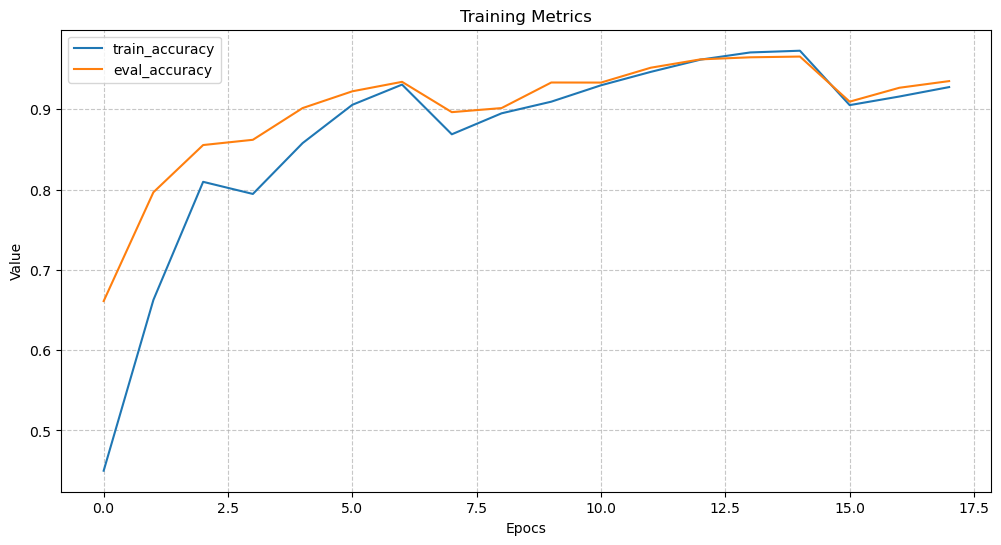

Valor final F1 en set de validación: 0.92. Mejor valor: 0.96.


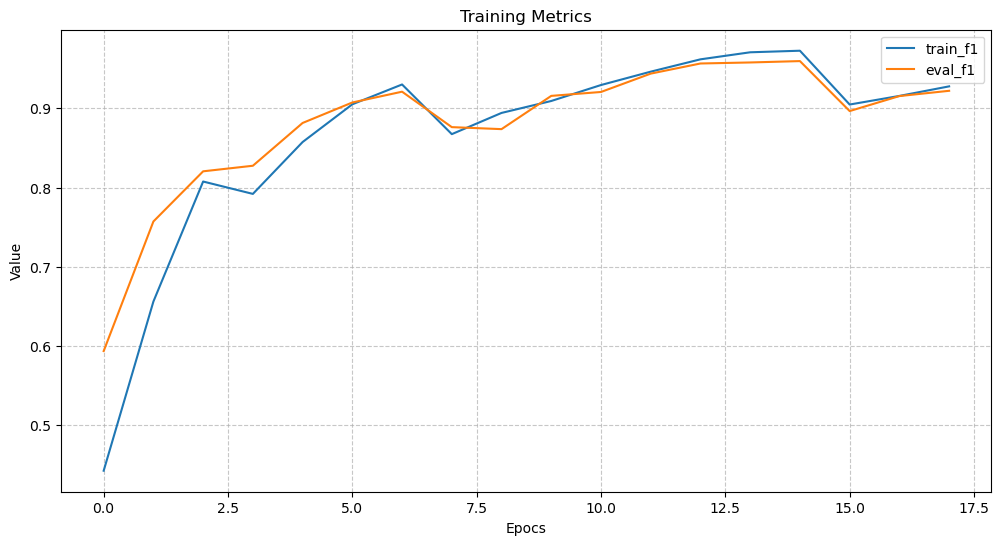

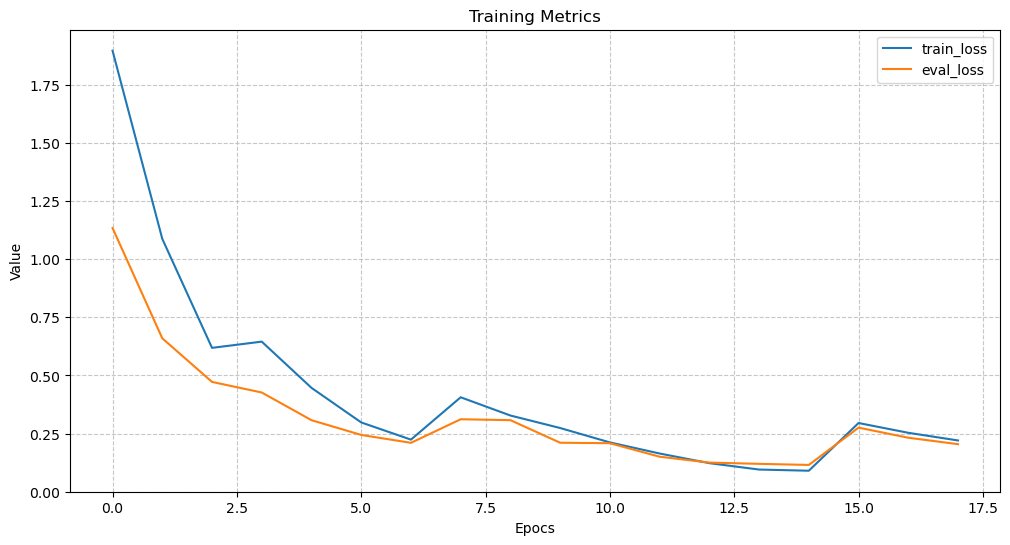

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.84      0.94      0.89       126
                                 Apple___Black_rot       0.98      1.00      0.99       124
                          Apple___Cedar_apple_rust       0.96      0.96      0.96        55
                                   Apple___healthy       0.97      0.93      0.95       329
                               Blueberry___healthy       0.98      0.98      0.98       300
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       210
                 Cherry_(including_sour)___healthy       0.97      0.98      0.97       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.82      0.93      0.87       103
                       Corn_(maize)___Common_rust_       0.99      0.98      0.99       238
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.90      0.

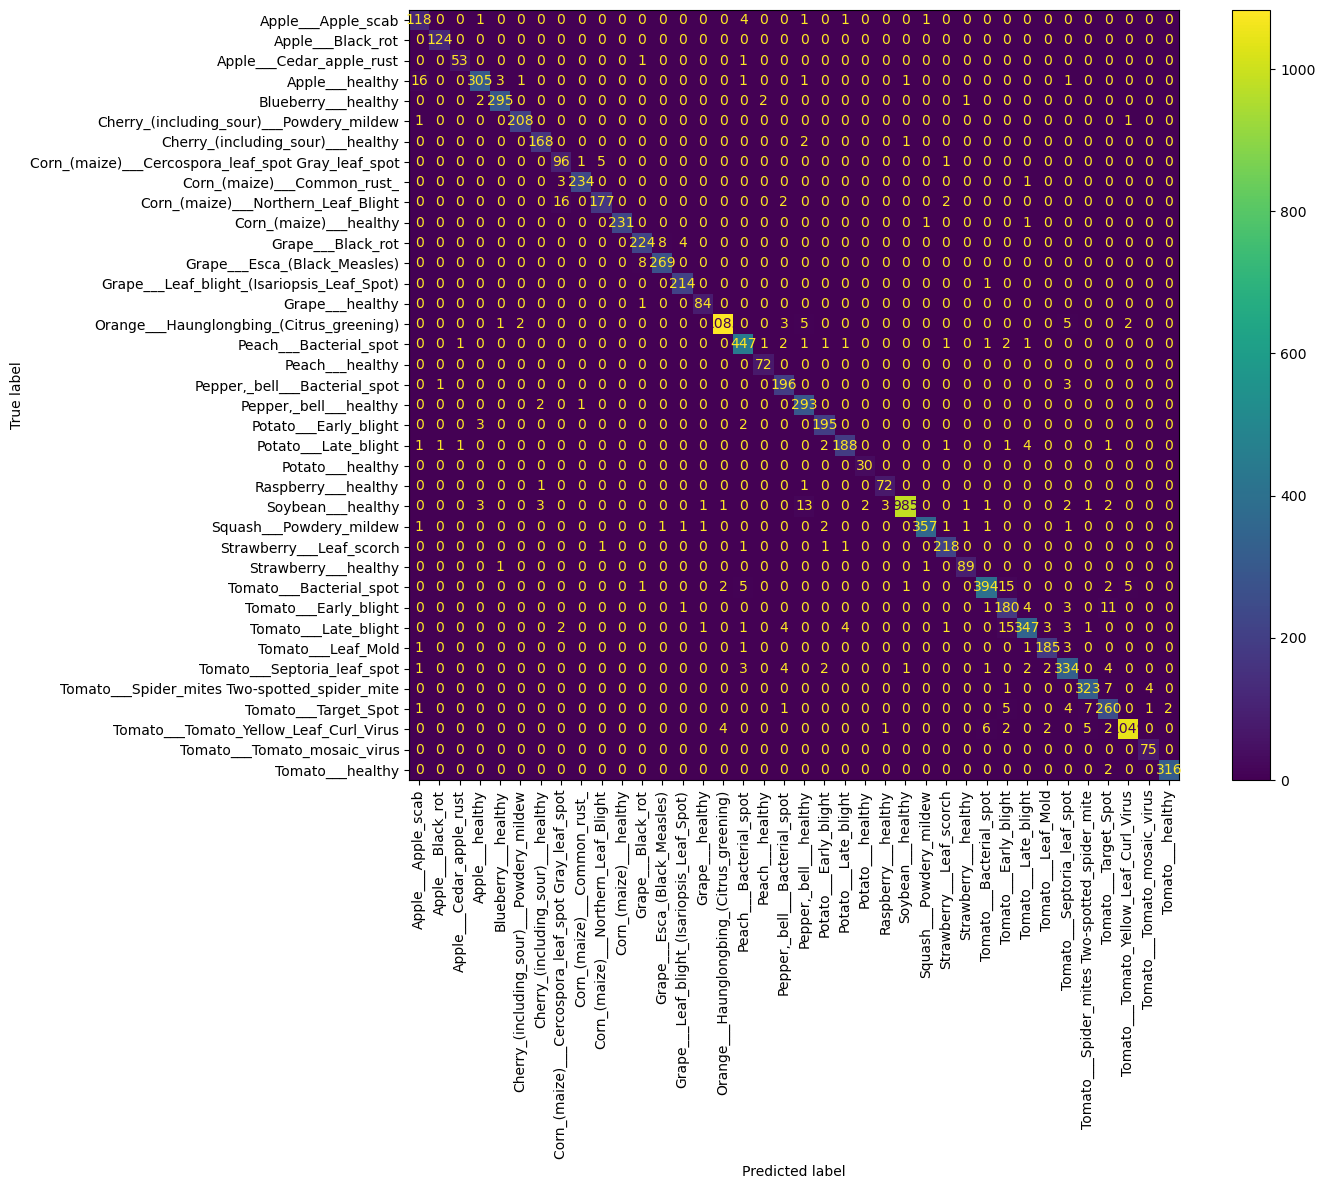

In [31]:
from sklearn.metrics import classification_report

print(f"Valor final accuracy en set de validación: {metrics_simple_cnn_opt.get_latest('eval_accuracy'):.3f}. Mejor valor: {np.max(metrics_simple_cnn_opt.get_all('eval_accuracy')):.3f}.")
metrics_simple_cnn_opt.plot_metrics(["train_accuracy", "eval_accuracy"])

print(f"Valor final F1 en set de validación: {metrics_simple_cnn_opt.get_latest('eval_f1'):.2f}. Mejor valor: {np.max(metrics_simple_cnn_opt.get_all('eval_f1')):.2f}.")
metrics_simple_cnn_opt.plot_metrics(["train_f1", "eval_f1"])

metrics_simple_cnn_opt.plot_metrics(["train_loss", "eval_loss"])

print(classification_report(simple_cnn_opt_eval_y, simple_cnn_opt_eval_y_pred, target_names=idx_to_class.values()))

plot_cm(simple_cnn_opt_eval_y, simple_cnn_opt_eval_y_pred)

#### Visualización y prueba del modelo sobre imágenes de test

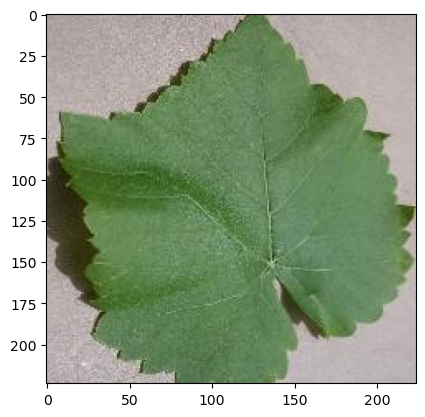

Predicted label: 14 (Grape___healthy).
Real label: 14 (Grape___healthy)


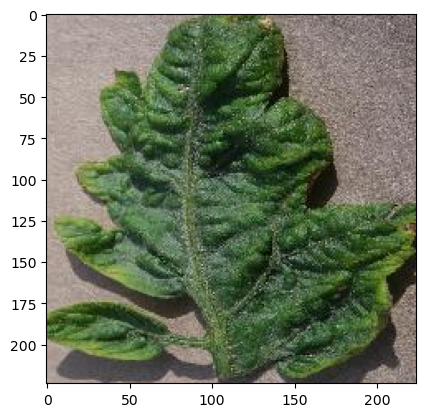

Predicted label: 35 (Tomato___Tomato_Yellow_Leaf_Curl_Virus).
Real label: 35 (Tomato___Tomato_Yellow_Leaf_Curl_Virus)


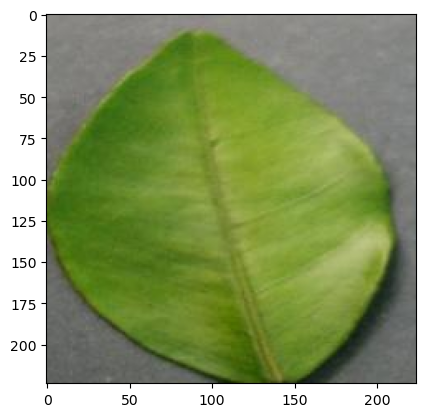

Predicted label: 15 (Orange___Haunglongbing_(Citrus_greening)).
Real label: 15 (Orange___Haunglongbing_(Citrus_greening))


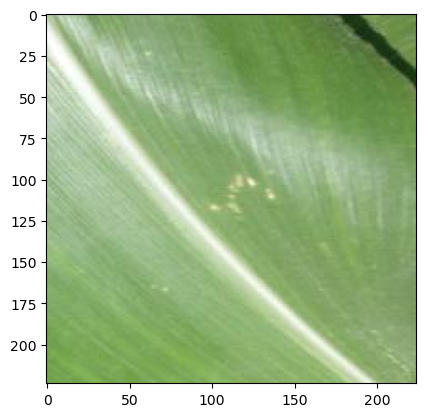

Predicted label: 10 (Corn_(maize)___healthy).
Real label: 10 (Corn_(maize)___healthy)


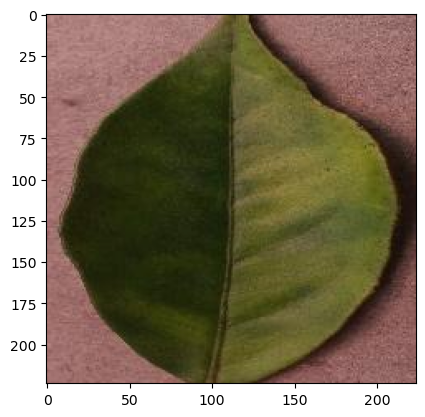

Predicted label: 15 (Orange___Haunglongbing_(Citrus_greening)).
Real label: 15 (Orange___Haunglongbing_(Citrus_greening))


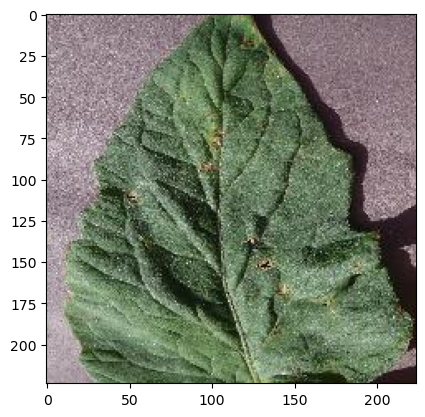

Predicted label: 34 (Tomato___Target_Spot).
Real label: 34 (Tomato___Target_Spot)


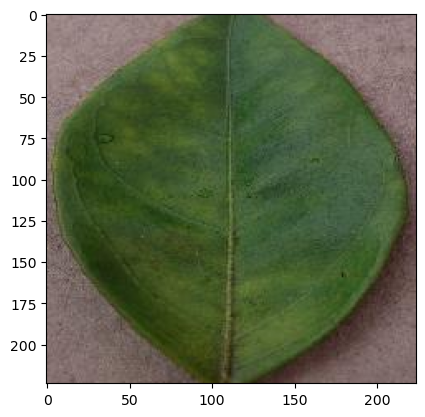

Predicted label: 15 (Orange___Haunglongbing_(Citrus_greening)).
Real label: 15 (Orange___Haunglongbing_(Citrus_greening))


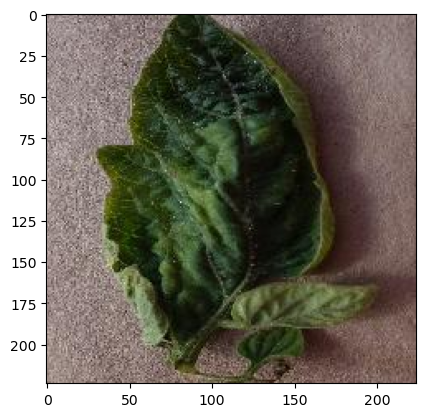

Predicted label: 35 (Tomato___Tomato_Yellow_Leaf_Curl_Virus).
Real label: 35 (Tomato___Tomato_Yellow_Leaf_Curl_Virus)


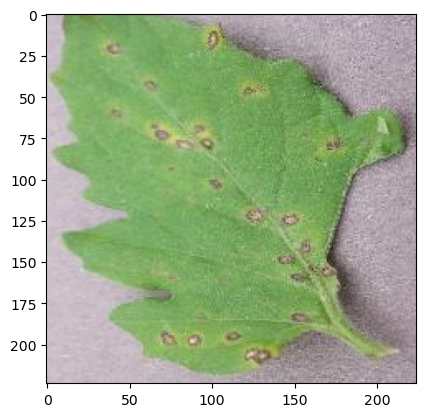

Predicted label: 32 (Tomato___Septoria_leaf_spot).
Real label: 32 (Tomato___Septoria_leaf_spot)


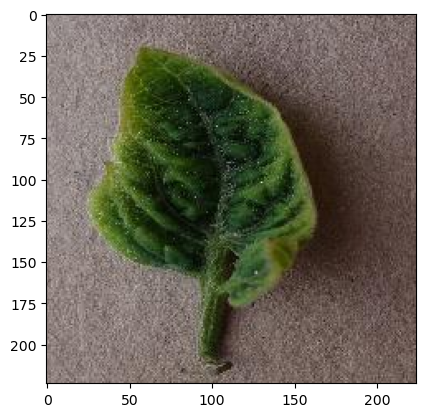

Predicted label: 35 (Tomato___Tomato_Yellow_Leaf_Curl_Virus).
Real label: 35 (Tomato___Tomato_Yellow_Leaf_Curl_Virus)


In [32]:
for _ in range(10):
    test_features, test_labels = next(iter(test_dataloader))
    img_test_idx = torch.randint(len(test_features), (1,))
    img_test = test_features[img_test_idx]
    label_test = test_labels[img_test_idx]
    label_test_pred = np.argmax(model_simple_cnn_opt(img_test.to(device)).detach().cpu().numpy())
    # ploteamos esa imagen
    img_test = img_test.squeeze().permute(1, 2, 0).numpy()
    img_test = (img_test * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    img_test = np.clip(img_test, 0, 1) # Clip values to be between 0 and 1
    plt.imshow(img_test)
    plt.show()
    print(f"Predicted label: {label_test_pred} ({idx_to_class[label_test_pred.item()]}).\nReal label: {label_test.item()} ({idx_to_class[label_test.item()]})")

## Conclusiones

La búsqueda de hiperparámetros para el LR arrojó un valor muy parecido al utilizado (0.00103 vs 0.001 anterior).  
El resultado del entrenamiento con el nuevo valor también fue similar.  
Incluso se estableció un máximo de 30 épocas para ver si tenia algún beneficio, y la máxima accuracy fue en la época 15, por lo que no tuvo beneficio.

Posiblemente se requiera una búsqueda con más épocas, porque se toma todas las épocas para mejorar.  
Mejor aun sería aprovechar la búsqueda de hiperparámetros para cantidad de capas o tamaños de kernels, lo que requeriría modificar el modelo y tiempo para realizar las pruebas.